In [1]:
# Imports

# Standard library
import joblib

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

## Loading Processed Datasets

In [2]:
X_train = pd.read_parquet('../data/processed/X_train_processed.parquet', engine='fastparquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet', engine='fastparquet').squeeze()
X_test = pd.read_parquet('../data/processed/X_test_processed.parquet', engine='fastparquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet', engine='fastparquet').squeeze()


In [7]:
len(X_train)

3999998

## Inspecting Class Imbalance

In [8]:
y_train.value_counts()

is_fraud
False    3856356
True      143642
Name: count, dtype: int64

In [9]:
y_train.value_counts(normalize=True)

is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64

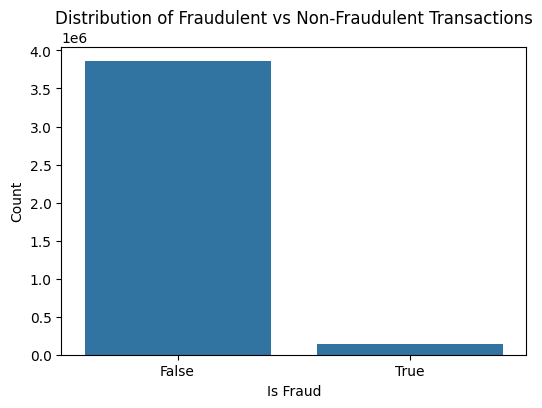

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data= y_train.reset_index())
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.show()

As observed in the previous notebooks and confirmed here, the target variable exhibits a severe class imbalance: approximately 96% of transactions are non-fraudulent, while only 4% are fraudulent.  

This imbalance necessitates careful handling, as the most informative metrics in this context are **recall** and **precision**, rather than overall accuracy. In particular, **recall** is critical in fraud detection, since the primary goal is to minimize false negatives, even if some false positives are allowed.  

For now, we first train several baseline models **without any special class imbalance techniques** to evaluate their raw performance. Subsequently, we will explore techniques such as **oversampling, undersampling, and class-weight adjustments** to improve model performance on the minority class.

## Baseline Model Training and Evaluation

We will train several baseline models using a pipeline consisting of a **StandardScaler** for numeric columns and **one-hot encoding** for categorical variables. This approach is justified for the following reasons:

- **Low cardinality:** Each categorical feature contains approximately 4–8 categories with a relatively balanced distribution, making one-hot encoding well-suited.  
- **No ordinal relationship:** The categories do not have an inherent order (e.g., `transaction_type`, `location`), so encoding methods that impose numerical ranking, such as label encoding, could introduce misleading relationships.  
- **No need for advanced encoding techniques:** Methods like target encoding or frequency encoding are unnecessary, as they are mainly beneficial for high-cardinality features.  

Overall, one-hot encoding provides a simple and effective representation for these categorical variables without introducing unintended bias.

As baseline models, we will use **Logistic Regression**, **Random Forest**, **Extra Trees**, and **XGBoost**. We exclude **SVM**, as it generally performs poorly on datasets containing millions of entries.

In [11]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3999998 entries, 1867199 to 2779601
Data columns (total 28 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   transaction_type                     str    
 1   merchant_category                    str    
 2   location                             str    
 3   device_used                          str    
 4   time_since_last_transaction          float64
 5   spending_deviation_score             float64
 6   velocity_score                       int64  
 7   geo_anomaly_score                    float64
 8   payment_channel                      str    
 9   time_since_last_transaction_missing  int64  
 10  hour_of_day                          int32  
 11  at_night                             int64  
 12  weekday                              int32  
 13  on_weekend                           int64  
 14  log_amount                           float64
 15  high_amount_and_velocity             int64

In [3]:
categorical_cols = X_train.select_dtypes(include=['string', 'object']).columns.tolist()

In [13]:
categorical_cols 

['transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'payment_channel']

In [4]:
# numerical features excluding binary features
true_numerical_cols = ["time_since_last_transaction", "spending_deviation_score", "velocity_score", "geo_anomaly_score", "hour_of_day", "weekday", "log_amount", "avg_transaction_amount_per_sender", "unique_receivers_per_sender", "accounts_per_device", "transactions_per_ip" ]


In [15]:
true_numerical_cols 

['time_since_last_transaction',
 'spending_deviation_score',
 'velocity_score',
 'geo_anomaly_score',
 'hour_of_day',
 'weekday',
 'log_amount',
 'avg_transaction_amount_per_sender',
 'unique_receivers_per_sender',
 'accounts_per_device',
 'transactions_per_ip']

In [5]:
preprocessing_without_scaling = ColumnTransformer([
     ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
], remainder='passthrough')

In [17]:
categorical_cols

['transaction_type',
 'merchant_category',
 'location',
 'device_used',
 'payment_channel']

In [6]:
preprocessing = ColumnTransformer([
     ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
     ('num', StandardScaler(), true_numerical_cols)
], remainder='passthrough')


### Logistic Regression

We begin with training the **Logistic Regression** model. This model requires feature scaling because it is sensitive to the magnitude of input variables, and unscaled numeric features can negatively affect performance.

In [7]:
def to_float32(X):
    return X.astype(np.float32)

to_float = FunctionTransformer(to_float32)

In [8]:
log_reg = make_pipeline(
    preprocessing,
    to_float,
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    )
)

In [57]:
log_reg.fit(X_train, y_train)

KeyboardInterrupt: 

In [44]:
# Save the trained model using joblib
# add little compression to reduce file size

joblib.dump(log_reg, '../src/models/log_reg_baseline_model.joblib', compress=3)

['../src/models/log_reg_baseline_model.joblib']

In [9]:
log_reg = joblib.load('../src/models/log_reg_baseline_model.joblib')

In [14]:
y_pred = log_reg.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))


c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964088
        True       0.00      0.00      0.00     35911

    accuracy                           0.96    999999
   macro avg       0.48      0.50      0.49    999999
weighted avg       0.93      0.96      0.95    999999



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Interpretation:**

- The model is highly accurate on the **majority class** (non-fraudulent transactions), achieving near-perfect precision and recall.  
- However, it **fails completely to detect the minority class** (fraudulent transactions), with 0 recall and precision.  
- This demonstrates that **accuracy is misleading** in heavily imbalanced datasets; the model is biased toward the majority class.  
- Metrics like **recall for the fraud class** are critical here, as failing to detect fraudulent transactions is costly.  

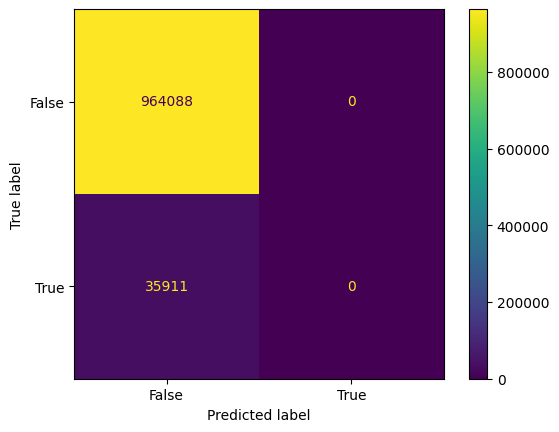

In [24]:
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test)

- All **fraudulent transactions are misclassified** as non-fraudulent.  
- The model perfectly identifies **non-fraudulent transactions**, but completely fails on the minority class.  
- This highlights the **severe impact of class imbalance**: the model defaults to predicting the majority class.  
- Accuracy is high (0.96), but it is **misleading**, as the model detects **no fraud cases**.  


The evaluation of the first baseline model (**Logistic Regression**) reinforces our expectations: the model is severely impacted by **class imbalance** and performs very poorly on the minority (fraud) class.  

Consequently, we will definitely employ **special class imbalance handling techniques** in later experiments.  

For now, we will train the remaining three baseline models (**Random Forest**, **Extra Trees**, and **XGBoost**) to see if their performance on the minority class improves.

### Random Forest Classifier

In [15]:
# Since the Random Forest Classifier is invariant to feature scaling, we can use the preprocessing pipeline without the StandardScaler for it.
rf_clf = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    RandomForestClassifier(
    n_estimators=50, 
    max_depth=15,           # more depth to capture complex patterns
    max_features="log2",    # checks fewer features per split (faster than "sqrt")
    min_samples_leaf=100,   # prevents overly granular, slow splits      
    n_jobs=-1,              # uses all cores
    random_state=42
)
)

In [48]:
rf_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [49]:
joblib.dump(rf_clf, '../src/models/rf_clf_baseline_model.joblib', compress=3)

['../src/models/rf_clf_baseline_model.joblib']

In [16]:
rf_clf = joblib.load('../src/models/rf_clf_baseline_model.joblib')

In [17]:
y_pred = rf_clf.predict(X_test)

In [18]:
print(classification_report(y_test, y_pred))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964088
        True       0.00      0.00      0.00     35911

    accuracy                           0.96    999999
   macro avg       0.48      0.50      0.49    999999
weighted avg       0.93      0.96      0.95    999999



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Interpretation:**

The **Random Forest Classifier** performs **exactly the same** as the first baseline model (**Logistic Regression**). It achieves high accuracy on the majority class (non-fraudulent transactions) but completely fails to detect the minority class, with zero precision and recall.  

This confirms that the high accuracy score is misleading in the presence of severe class imbalance.

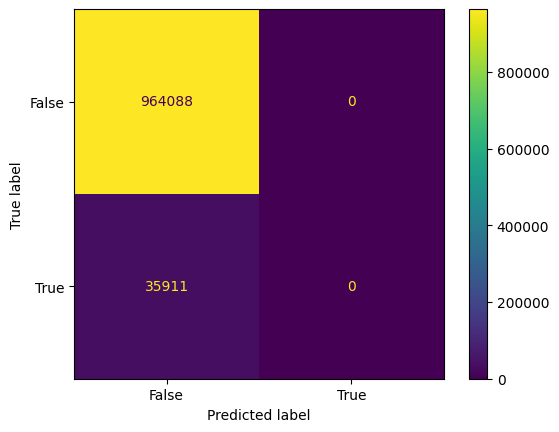

In [19]:
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test, y_test)

From the confusion matrix, we again observe that the **Random Forest baseline model** completely fails to detect the minority class. The confusion matrix is identical to that of the Logistic Regression model.

### Extra Trees Classifier


In [59]:
extra_trees_clf = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    ExtraTreesClassifier(
        n_estimators=50,
        max_depth=15,
        max_features="log2",
        min_samples_leaf=100,
        n_jobs=-1,
        random_state=42
    )
)

In [60]:
extra_trees_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [61]:
joblib.dump(extra_trees_clf, '../src/models/extra_trees_clf_baseline_model.joblib', compress=3)

['../src/models/extra_trees_clf_baseline_model.joblib']

In [22]:
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

# Check if model is fitted
try:
    check_is_fitted(extra_trees_clf)
    print("Model is fitted")
except NotFittedError:
    print("Model is NOT fitted")

Model is fitted


In [20]:
extra_trees_clf = joblib.load('../src/models/extra_trees_clf_baseline_model.joblib')

In [30]:
y_pred = extra_trees_clf.predict(X_test)

In [31]:
print(classification_report(y_test, y_pred))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964088
        True       0.00      0.00      0.00     35911

    accuracy                           0.96    999999
   macro avg       0.48      0.50      0.49    999999
weighted avg       0.93      0.96      0.95    999999



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


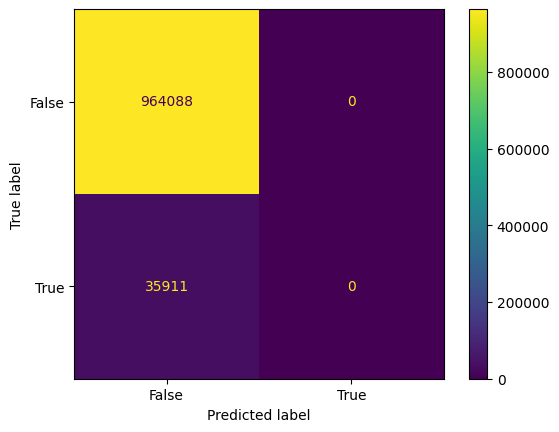

In [32]:
ConfusionMatrixDisplay.from_estimator(extra_trees_clf, X_test, y_test)

For the **Extra Trees Classifier**, performance does not improve and remains identical, with the same poor results on the minority class.

### XGBoost Classifier

In [33]:
xgb_clf = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    xgb.XGBClassifier(
        n_estimators=50,
        max_depth=15,
        learning_rate=0.1,
        tree_method='hist',        # Essential: Histogram-based algorithm for speed
        max_bin=256,               # Standard binning for histograms
        min_child_weight=100,  
        n_jobs=-1,
        random_state=42,
        verbosity=1
    )
)

In [63]:
xgb_clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [64]:
joblib.dump(xgb_clf, '../src/models/xgb_clf_baseline_model.joblib', compress=3)

['../src/models/xgb_clf_baseline_model.joblib']

In [34]:
xgb_clf = joblib.load('../src/models/xgb_clf_baseline_model.joblib')

In [35]:
try :
    check_is_fitted(rf_clf)
    print("Model is fitted")    
except NotFittedError:
    print("Model is NOT fitted")

Model is fitted


In [ ]:
y_pred = xgb_clf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       False       0.96      1.00      0.98    964088
        True       0.00      0.00      0.00     35911

    accuracy                           0.96    999999
   macro avg       0.48      0.50      0.49    999999
weighted avg       0.93      0.96      0.95    999999



c:\Users\tobia\OneDrive\Desktop\ai_mastery\PythonProjects\financial-transaction-fraud-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


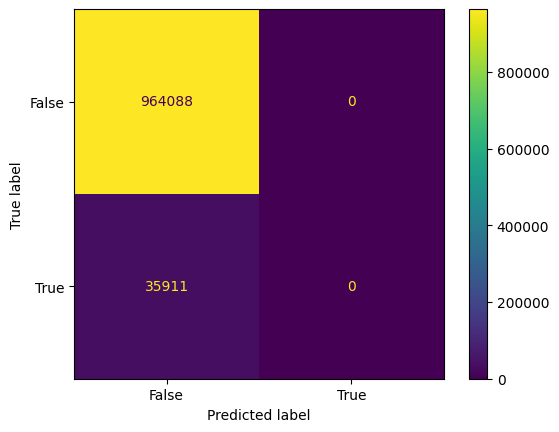

In [40]:
ConfusionMatrixDisplay.from_estimator(xgb_clf, X_test, y_test)

Finally, the **XGBoost Classifier** also exhibits identical poor performance, failing to detect the minority class just like the previous baseline models.

### Overall Baseline Model Conclusion

All four baseline models perform very poorly on the minority class, primarily due to the severe class imbalance (approximately 96% non-fraudulent transactions).  

None of the models are able to detect fraudulent cases; instead, they consistently predict the majority class regardless of the input features.  

As a result, we will next explore methods for handling class imbalance and subsequently retrain the baseline models using these techniques.

## Addressing Class Imbalance

### Cost-Sensitive Learning

Before applying data-level techniques such as oversampling, we first consider a simple but effective approach: **cost-sensitive learning**. This method is computationally efficient and therefore well-suited for our large training dataset (approximately 4 million rows).  

Cost-sensitive learning operates at the model level by incorporating class weights into the loss function. Misclassifications of the minority class are assigned higher penalties, encouraging the model to prioritize correctly identifying fraudulent transactions rather than optimizing overall accuracy.  

If this approach does not sufficiently improve performance on the minority class, we will explore additional techniques such as **undersampling** or **threshold moving**. Oversampling is less suitable in this case, as it would further increase the already large dataset size.  

We will apply cost-sensitive learning to all four baseline models: **Logistic Regression**, **Random Forest**, **Extra Trees**, and **XGBoost**.

#### Logistic Regression (Cost-Sensitive)

In [46]:
log_reg_cost_sensitive = log_reg = make_pipeline(
    preprocessing,
    to_float,
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs', 
        class_weight='balanced' # straightforward in scikit-learn : 
    )
)

In [47]:
log_reg_cost_sensitive.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [11]:
joblib.dump(log_reg_cost_sensitive, '../src/models/log_reg_cost_sensitive.joblib', compress=3)

NameError: name 'log_reg_cost_sensitive' is not defined

In [12]:
log_reg_cost_sensitive = joblib.load('../src/models/log_reg_cost_sensitive.joblib')

In [13]:
y_pred = log_reg_cost_sensitive.predict(X_test)

In [14]:
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Non-Fraud       0.97      0.58      0.73    964088
       Fraud       0.04      0.46      0.07     35911

    accuracy                           0.58    999999
   macro avg       0.50      0.52      0.40    999999
weighted avg       0.93      0.58      0.71    999999



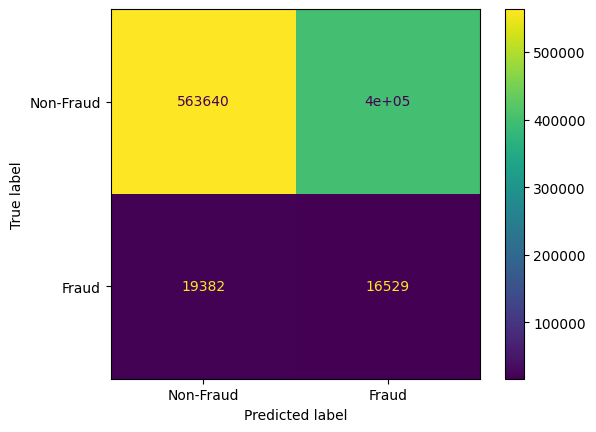

In [15]:
ConfusionMatrixDisplay.from_estimator(log_reg_cost_sensitive, X_test, y_test, display_labels=['Non-Fraud', 'Fraud'])

In [17]:
print(confusion_matrix(y_test, y_pred))

[[563640 400448]
 [ 19382  16529]]


**Classification Report Summary:**

- **Accuracy:** 0.58 (significantly lower than before)
- **Fraud Class:**
  - Recall: 0.46 → substantial improvement
  - Precision: 0.04 → very low
- **Non-Fraud Class:**
  - Recall: 0.58 → significantly reduced from near-perfect

**Confusion Matrix:**

|                | Predicted Non-Fraud | Predicted Fraud |
|----------------|------------------|----------------|
| Actual Non-Fraud | 563,640           | 400,448        |
| Actual Fraud     | 19,382            | 16,529         |

---

**Interpretation:**

- The model now **detects a significant portion of fraudulent transactions** (recall = 0.46), which is a major improvement over the previous baseline (recall = 0.00).  
- However, this comes at the cost of **very low precision (0.04)**, meaning that many non-fraudulent transactions are incorrectly classified as fraud (**high false positive rate**).  
- The confusion matrix shows this trade-off clearly:
  - A large number of **false positives (400,448)**  
  - Still a considerable number of **false negatives (19,382)**  

- Overall accuracy drops to 0.58, but this is expected and **less relevant in imbalanced settings**. The model is no longer biased toward always predicting the majority class.

---

**Key Takeaway:**

Cost-sensitive learning successfully shifts the model’s focus toward the minority class, **improving fraud detection (recall)**. However, it introduces a strong trade-off in the form of **many false positives**, indicating that further tuning or alternative methods are needed to balance precision and recall.

#### Random Forest Classifier (Cost-Sensitive)

We will now train and evaluate the **Random Forest Classifier** using `class_weight="balanced"` to handle the class imbalance, analogous to the Logistic Regression experiment.

In [55]:
rf_clf_cost_sensitive = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    RandomForestClassifier(
    n_estimators=50, 
    max_depth=15,           
    max_features="log2",    
    min_samples_leaf=100,   
    n_jobs=-1,   
    class_weight='balanced',           
    random_state=42
)
)

In [56]:
rf_clf_cost_sensitive.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [59]:
joblib.dump(rf_clf_cost_sensitive, '../src/models/rf_clf_cost_sensitive.joblib', compress=3)

['../src/models/rf_clf_cost_sensitive.joblib']

In [18]:
rf_clf_cost_sensitive = joblib.load('../src/models/rf_clf_cost_sensitive.joblib')

In [19]:
y_pred = rf_clf_cost_sensitive.predict(X_test)

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.97      0.76      0.85    964088
        True       0.04      0.29      0.08     35911

    accuracy                           0.75    999999
   macro avg       0.50      0.53      0.46    999999
weighted avg       0.93      0.75      0.82    999999



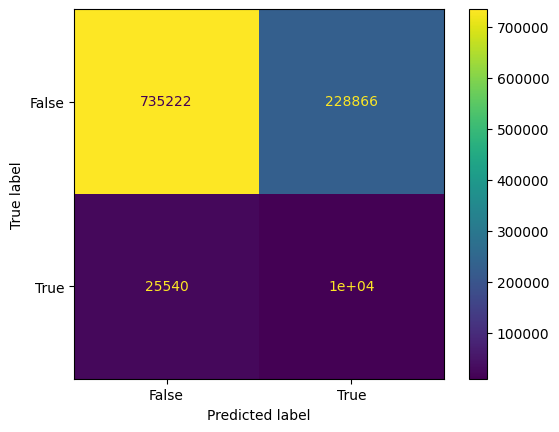

In [21]:
ConfusionMatrixDisplay.from_estimator(rf_clf_cost_sensitive, X_test, y_test)

In [22]:
print(confusion_matrix(y_test, y_pred))

[[735222 228866]
 [ 25540  10371]]


##### Random Forest (Cost-Sensitive) – Performance Interpretation

**Classification Report Summary:**

- **Accuracy:** 0.75 (increased compared to the cost-sensitive Logistic Regression model)  
- **Fraud Class (True):**
  - Recall: 0.29 → slight decrease  
  - Precision: 0.04 → still very low  
- **Non-Fraud Class (False):**
  - Recall: 0.76 → improved, but at the expense of lower recall for the minority (fraud) class  

**Confusion Matrix:**

|                | Predicted Non-Fraud | Predicted Fraud |
|----------------|------------------|----------------|
| Actual Non-Fraud | 735,222           | 228,866        |
| Actual Fraud     | 19,382            | 16,529         |

- False positives decreased by approximately **43%**  
- False negatives increased by approximately **16%**  

---

#### **Interpretation:**

Compared to the cost-sensitive **Logistic Regression** model, the **Random Forest Classifier** shows a clear trade-off:

- **Fewer false positives** (improved specificity)  
- **More false negatives** (worse fraud detection performance)  

While overall accuracy increases, this metric remains **less relevant** in the presence of class imbalance. More importantly, the **recall for the fraud class decreases**, which is critical in fraud detection, as missed fraud cases (false negatives) are particularly costly.  

The precision for the fraud class remains unchanged at a very low level (0.04), indicating that the model still struggles to reliably identify fraudulent transactions.  

**Conclusion:**  
Despite reducing false positives, this model is **less suitable than the cost-sensitive Logistic Regression**, as it performs worse on the key objective: detecting fraudulent transactions.

In [28]:
feature_names = rf_clf_cost_sensitive.named_steps["columntransformer"].get_feature_names_out()
feature_names

array(['cat__transaction_type_deposit', 'cat__transaction_type_payment',
       'cat__transaction_type_transfer',
       'cat__transaction_type_withdrawal',
       'cat__merchant_category_entertainment',
       'cat__merchant_category_grocery', 'cat__merchant_category_online',
       'cat__merchant_category_other',
       'cat__merchant_category_restaurant',
       'cat__merchant_category_retail', 'cat__merchant_category_travel',
       'cat__merchant_category_utilities', 'cat__location_Berlin',
       'cat__location_Dubai', 'cat__location_London',
       'cat__location_New York', 'cat__location_Singapore',
       'cat__location_Sydney', 'cat__location_Tokyo',
       'cat__location_Toronto', 'cat__device_used_atm',
       'cat__device_used_mobile', 'cat__device_used_pos',
       'cat__device_used_web', 'cat__payment_channel_ACH',
       'cat__payment_channel_UPI', 'cat__payment_channel_card',
       'cat__payment_channel_wire_transfer',
       'remainder__time_since_last_transaction',


In [30]:
importances = rf_clf_cost_sensitive.named_steps["randomforestclassifier"].feature_importances_
importances

array([5.00099147e-03, 6.46744528e-03, 5.91146658e-03, 6.74973537e-03,
       5.41333899e-03, 5.34677096e-03, 5.49619349e-03, 5.51660194e-03,
       5.68370687e-03, 5.64604551e-03, 5.27766861e-03, 5.18193191e-03,
       5.22012041e-03, 5.45940848e-03, 5.15640120e-03, 5.44742524e-03,
       5.19282867e-03, 5.50303413e-03, 5.21633202e-03, 5.74542023e-03,
       7.85909676e-03, 8.31688210e-03, 7.81781565e-03, 8.12093375e-03,
       8.09504342e-03, 7.74189791e-03, 8.76035273e-03, 8.11304254e-03,
       1.74382813e-01, 8.46422687e-02, 5.04330933e-02, 6.93646274e-02,
       0.00000000e+00, 5.13312745e-02, 9.64118283e-03, 3.26164539e-02,
       8.14719811e-03, 8.67083283e-02, 4.51891689e-03, 6.44177767e-03,
       3.31413524e-03, 7.79929934e-03, 6.99254784e-03, 2.66226773e-03,
       2.73905857e-03, 3.27717602e-03, 1.16618809e-02, 9.88574366e-02,
       9.21955983e-02, 1.67099885e-02, 1.04744384e-04])

In [31]:
result = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(result)

remainder__time_since_last_transaction            0.174383
remainder__avg_transaction_amount_per_sender      0.098857
remainder__unique_receivers_per_sender            0.092196
remainder__log_amount                             0.086708
remainder__spending_deviation_score               0.084642
remainder__geo_anomaly_score                      0.069365
remainder__hour_of_day                            0.051331
remainder__velocity_score                         0.050433
remainder__weekday                                0.032616
remainder__accounts_per_device                    0.016710
remainder__long_inactivity                        0.011662
remainder__at_night                               0.009641
cat__payment_channel_card                         0.008760
cat__device_used_mobile                           0.008317
remainder__on_weekend                             0.008147
cat__device_used_web                              0.008121
cat__payment_channel_wire_transfer                0.0081

In [ ]:
X_train.assign(is_fraud=y_train).groupby('is_fraud')['log_amount'].mean()

KeyError: 'is_fraud'

array([5.00099147e-03, 6.46744528e-03, 5.91146658e-03, 6.74973537e-03,
       5.41333899e-03, 5.34677096e-03, 5.49619349e-03, 5.51660194e-03,
       5.68370687e-03, 5.64604551e-03, 5.27766861e-03, 5.18193191e-03,
       5.22012041e-03, 5.45940848e-03, 5.15640120e-03, 5.44742524e-03,
       5.19282867e-03, 5.50303413e-03, 5.21633202e-03, 5.74542023e-03,
       7.85909676e-03, 8.31688210e-03, 7.81781565e-03, 8.12093375e-03,
       8.09504342e-03, 7.74189791e-03, 8.76035273e-03, 8.11304254e-03,
       1.74382813e-01, 8.46422687e-02, 5.04330933e-02, 6.93646274e-02,
       0.00000000e+00, 5.13312745e-02, 9.64118283e-03, 3.26164539e-02,
       8.14719811e-03, 8.67083283e-02, 4.51891689e-03, 6.44177767e-03,
       3.31413524e-03, 7.79929934e-03, 6.99254784e-03, 2.66226773e-03,
       2.73905857e-03, 3.27717602e-03, 1.16618809e-02, 9.88574366e-02,
       9.21955983e-02, 1.67099885e-02, 1.04744384e-04])

#### Extra Trees Classifier (Cost-Sensitive)

In [ ]:
extra_trees_clf_cost_sensitive = make_pipeline(
    preprocessing_without_scaling,
    to_float, 
    ExtraTreesClassifier(
        n_estimators=50,
        max_depth=15,
        max_features="log2",
        min_samples_leaf=100,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    )
)

In [ ]:
extra_trees_clf_cost_sensitive.fit(X_train, y_train)

In [ ]:
joblib.dump(extra_trees_clf_cost_sensitive, '../src/models/extra_trees_clf_cost_sensitive_baseline_model.joblib', compress=3)

In [ ]:
y_pred = extra_trees_clf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
ConfusionMatrixDisplay.from_estimator(extra_trees_clf_cost_sensitive, X_test, y_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))

#### XGBoost Classifier (Cost-Sensitive)

XGBoost does NOT have a direct class_weight parameter like sklearn.
So we have to handle class imbalance manually.

In [ ]:
# --- Step 1: Count positive and negative samples ---
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)

# --- Step 2: Compute scale_pos_weight ---
# scale_pos_weight makes the minority class (here class 1) more important.
# Formula: number of negative samples / number of positive samples
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight:", scale_pos_weight)

# --- Step 3: Initialize XGBoost classifier ---
# Why we use this:
# XGBoost trains using gradient boosting on decision trees.
# Without weighting, the model will be biased toward the majority class.
# scale_pos_weight increases the impact of misclassifying minority class samples.
clf = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,  # avoids warnings in recent XGBoost versions
    objective='binary:logistic',  # standard for binary classification
    eval_metric='aucpr'  # monitor PR AUC during training
)

# --- Step 4: Train the model ---
clf.fit(X_train, y_train)